## Introduction

In this project, we will be analyzing some data from a sample of anonymous patients who were evaluated for heart disease at the `Cleveland Clinic Foundation`. This processed data has been downloaded from the `UCI Machine Learning Repository`.

In this project our primary areas of focus will be as followed:

- Analyzing `thalach` to understand some of the more accurate predictors of heart disease
- Investigating the relationship between maximum heart rate and the kind of chest pain that a patient experiences
- Investigating the relationship between the kind of chest pain that a patient experiences and if they have heart disease or not

### Data Features

The following list will introduce the features (columns) of our dataset and give a brief explanation of each feature:

- `age`: The patient's age in years
- `sex`: The patient's sex assigned at birth (`1` for male and `0` for female)
- `trestbps`: The patient's resting blood pressure in mm Hg
- `chol`: The patient's serum cholseterol in mg/dl
- `cp`: The kind of chest pain that the patient is experiencing (`1`: typical angina, `2`: atypical angina, `3`: non-anginal pain, `4`: asymptomatic)
- `exang`: Whether the patient experiences exercise-induced angina (`1`: yes, `0`: no)
- `fbs`: Whether the patient's fasting blood sugar is > 120 mg/dl (`1`: yes, `0`: no)
- `thalach`: The patient's maximum heart rate achieved in exercise test
- `heart_disease`: Whether the patient is found to have heart disease (`1`: yes, `0`: no)

In [ ]:
#Installing Necessary Packages
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scipy
%pip install statsmodels

In [2]:
#Importing the Installed Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

%matplotlib inline


## Formatting the Data

The first thing that we need to do is load our data set into a pandas DataFrame.

Here, our intial DataFrame will be named, `heart`.

In [3]:
# Create a path to the data file because it is not a .csv extention
file_path = 'processed.cleveland.data'

# Read the data into a pandas DataFrame
heart = pd.read_csv(file_path, delimiter=',', header=None)

#Display the first few rows of our new DataFrame
print(heart.head())

     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0


From this initial DataFrame, we can see that our column headers are empty as we had specified not to have any when creating our DataFrame. Let's fix that.

In [4]:
# Defining column headers
column_names = ['age', 'sex', 'cp_type', 'trestbps', 'chol', 'fbs', 'u1', 'thalach', 
                'exang', 'u2', 'u3', 'u4', 'u5', 'heart_disease']

#Assigning the headers to our DataFrame
heart.columns = column_names

#Displaying our updated DataFrame
print(heart.head())



    age  sex  cp_type  trestbps   chol  fbs   u1  thalach  exang   u2   u3  \
0  63.0  1.0      1.0     145.0  233.0  1.0  2.0    150.0    0.0  2.3  3.0   
1  67.0  1.0      4.0     160.0  286.0  0.0  2.0    108.0    1.0  1.5  2.0   
2  67.0  1.0      4.0     120.0  229.0  0.0  2.0    129.0    1.0  2.6  2.0   
3  37.0  1.0      3.0     130.0  250.0  0.0  0.0    187.0    0.0  3.5  3.0   
4  41.0  0.0      2.0     130.0  204.0  0.0  2.0    172.0    0.0  1.4  1.0   

    u4   u5  heart_disease  
0  0.0  6.0              0  
1  3.0  3.0              2  
2  2.0  7.0              1  
3  0.0  3.0              0  
4  0.0  3.0              0  


Now, you may notice that there are columns labeled `u1`, `u2`, `u3`, `u4`, and `u5`.

These are simply columns to which the values stored will not be needed for the analysis conducted in this project.

So let's just go ahead and remove those columns.

In [5]:
# Defining the columns that we want to be removed
columns_to_remove = ['u1', 'u2', 'u3', 'u4', 'u5']

# Removing the columns from our DataFrame
heart = heart.drop(columns = columns_to_remove)

#Displaying our updated DataFrame
print(heart.head())

    age  sex  cp_type  trestbps   chol  fbs  thalach  exang  heart_disease
0  63.0  1.0      1.0     145.0  233.0  1.0    150.0    0.0              0
1  67.0  1.0      4.0     160.0  286.0  0.0    108.0    1.0              2
2  67.0  1.0      4.0     120.0  229.0  0.0    129.0    1.0              1
3  37.0  1.0      3.0     130.0  250.0  0.0    187.0    0.0              0
4  41.0  0.0      2.0     130.0  204.0  0.0    172.0    0.0              0


As previously mentioned in the introduction portion of this project, the column `cp type` describes the type of chest pain that each patient is experiencing. As a reminder:
- `1`: typical angina
- `2`: atypical angina
- `3`: non-anginal pain
- `4`: asymptomatic

To make our analysis easier to interpret, we will change the numerical values in this column to text values representative of thier corresponding pain type.

In [6]:
# Creating a dcitionary to easliy map old column names to new column names
mapping = {1.0: 'typical angina', 2.0: 'atypical angina', 3.0: 'non-anginal pain', 4.0: 'asymptomatic'}

# Replacing the numerical values with the text values
heart['cp_type'] = heart['cp_type'].map(mapping)

# Displaying our updated DataFrame
print(heart.head())

    age  sex           cp_type  trestbps   chol  fbs  thalach  exang  \
0  63.0  1.0    typical angina     145.0  233.0  1.0    150.0    0.0   
1  67.0  1.0      asymptomatic     160.0  286.0  0.0    108.0    1.0   
2  67.0  1.0      asymptomatic     120.0  229.0  0.0    129.0    1.0   
3  37.0  1.0  non-anginal pain     130.0  250.0  0.0    187.0    0.0   
4  41.0  0.0   atypical angina     130.0  204.0  0.0    172.0    0.0   

   heart_disease  
0              0  
1              2  
2              1  
3              0  
4              0  


Last but not least within our data preparation, we will take care of the heart disease column. Here, we have values ranging from 0-4 where a value of `0` means that a patient does not have detectable heart disease, whereas any number greater than zero up to four (`1`, `2`, `3`, `4`) not only means that a patient has detectable hear disease, but also represents the severity of the heart disease with a value of `4` being the most severe.

In our analysis here, we will only be analyzing whethere a patient has heart disease or not, and we will not be taking into account how severe that heart disease is.

Therefore, we need the heart disease column to be binary, `0` for no detectable heart disease or `1` for detectable heart disease. Let's update our column to contain that format.

In [7]:
# Update the column using a lambda function
heart['heart_disease'] = heart['heart_disease'].apply(lambda x: 1 if x > 0 else 0)

# Displaying our updated DataFrame
print(heart.head())

    age  sex           cp_type  trestbps   chol  fbs  thalach  exang  \
0  63.0  1.0    typical angina     145.0  233.0  1.0    150.0    0.0   
1  67.0  1.0      asymptomatic     160.0  286.0  0.0    108.0    1.0   
2  67.0  1.0      asymptomatic     120.0  229.0  0.0    129.0    1.0   
3  37.0  1.0  non-anginal pain     130.0  250.0  0.0    187.0    0.0   
4  41.0  0.0   atypical angina     130.0  204.0  0.0    172.0    0.0   

   heart_disease  
0              0  
1              1  
2              1  
3              0  
4              0  


In addition to the transformations made above, to make this column even easier to interpret during our analysis, we will change all of the values in the `heart_disease` column to "present" for a current value of `1`, and we will change all current values of `0` to "absent."

In [8]:
# Update the column using a lambda function
heart['heart_disease'] = heart['heart_disease'].apply(lambda x: "present" if x == 1 else "absent")

# Displaying our updated DataFrame
print(heart.head())

    age  sex           cp_type  trestbps   chol  fbs  thalach  exang  \
0  63.0  1.0    typical angina     145.0  233.0  1.0    150.0    0.0   
1  67.0  1.0      asymptomatic     160.0  286.0  0.0    108.0    1.0   
2  67.0  1.0      asymptomatic     120.0  229.0  0.0    129.0    1.0   
3  37.0  1.0  non-anginal pain     130.0  250.0  0.0    187.0    0.0   
4  41.0  0.0   atypical angina     130.0  204.0  0.0    172.0    0.0   

  heart_disease  
0        absent  
1       present  
2       present  
3        absent  
4        absent  


And as a final measure of precaution, we will display the data types of each column in the datasent to ensure that the data types are what we need prior to starting our analysis.

In [9]:
# Checking the data type of each column
print(heart.dtypes)

age              float64
sex              float64
cp_type           object
trestbps         float64
chol             float64
fbs              float64
thalach          float64
exang            float64
heart_disease     object
dtype: object


## Data Analysis

The first thing that we will explore in our dataset is the the question: "Is `thalach` associated with whether or not a patient will ultimately be diagnosed with heart disease?"

To begin to investigate this question, we will first make two side-by-side box plots in order to compare the `thalach` measures of those patients who were and who were not diagnosed with heart disease.

When analyzing this boxplot, we can see that patients who were diagnosed with heart disease generally had lower maximum heart rates during the exercise test.

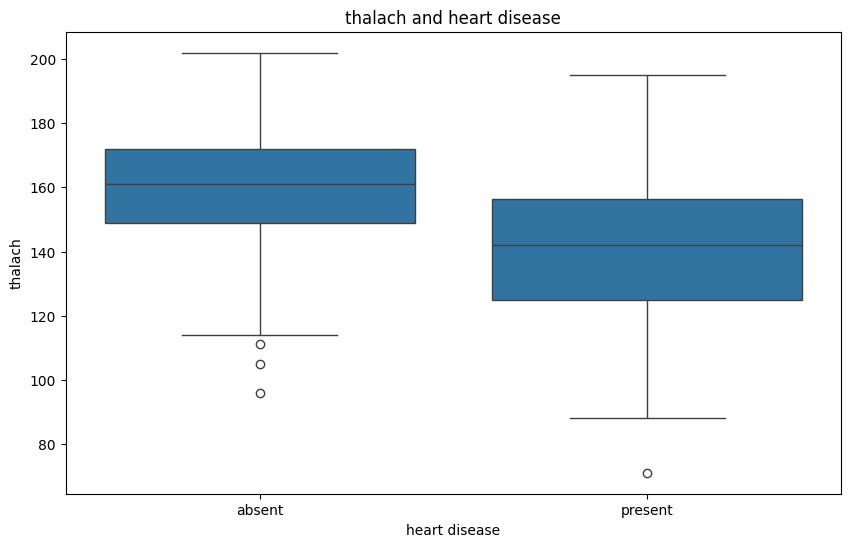

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='heart_disease', y='thalach', data=heart)
plt.title('thalach and heart disease')
plt.xlabel('heart disease')
plt.ylabel('thalach')
plt.show()

In order to investigate this question further, we will split our `thalach` data into two differenet variables; `thalach_hd` for the measusres of maximum heart rate for those who were diagnosed with heart disease, and `thalach_no_hd` for the measures of maximum heart rate for those who were not diagnosed with heart disease.

In [11]:
# Defining thalach_hd
thalach_hd = heart.thalach[heart.heart_disease == 'present']

# Defining thalach_no_hd
thalach_no_hd = heart.thalach[heart.heart_disease == 'absent']

To get a better idea of our measures of `thalach`, next we will calculated the mean and median for `thalach_hd` and for `thalach_no_hd`, as well as calculating the mean and median difference for the two subsets of data.

Here are the results of our findings:

Means:
- `thalach_hd_mean` = 139.26
- `thalach_no_hd_mean` = 158.39
- `mean_diff` = 19.12

Medians:
- `thalach_hd_median` = 142.0
- `thalach_no_hd_median` = 161.0
- `median_diff` = 19.0

In [12]:
# Calculating means
thalach_hd_mean = np.mean(thalach_hd)
thalach_no_hd_mean = np.mean(thalach_no_hd)

# Printing individual means
print(thalach_hd_mean)
print(thalach_no_hd_mean)

# Calculating mean difference
mean_diff = thalach_no_hd_mean - thalach_hd_mean

# Printing the mean difference
print(mean_diff)

139.25899280575538
158.3780487804878
19.11905597473242


In [13]:
# Calculating medians
thalach_hd_median = np.median(thalach_hd)
thalach_no_hd_median = np.median(thalach_no_hd)

# Printing individual medians
print(thalach_hd_median)
print(thalach_no_hd_median)

# Calculating median difference
median_diff = thalach_no_hd_median - thalach_hd_median

# Printing the median difference
print(median_diff)

142.0
161.0
19.0


To further analyze our data, we now would like to determine if the average `thalach` of a patient with heart disease is significantly different from the average `thalach` of a patient who does not have heart disease.

To determine this, we will be running a `two-tailed hypothesis test`. In order to run this test, we will need to state a Null and Alternative hypotheses which are as followed:

Null: The average `thalach` for a patient with heart disease IS equal to the average `thalach` of a patient who does not have heart disease.

Alternative: The average `thalach` for a patient with heart disease IS NOT equal to the average `thalach` of a patient who does not have heart disease.

The reason why we use a two-tail hypothesis test rather than a one-tailed hypothesis test in this scenario is due to the nature in which we are analyzing `thalach`. If we wanted to see if the `thalach` in heart disease patients was either strictly greater than or strictly less than the `thalach` in non-heart diseased patients, we would use a one-tailed hypothesis test. However, we are just checking for a difference in `thalach` which could be greater than or less than, which is why we are using a two-tailed hypothesis test.

In [14]:
# Running our two-tailed hypothesis test (previously imported: ttest_ind)
tstat, pval = ttest_ind(thalach_hd, thalach_no_hd)

# Printing the p-value
print(pval)

3.456964908430171e-14


Here, we can see that we have an extremely small p-value which means that the average `thalach` in heart diseased patients IS significantly different than the average `thalach` in non-heart diseased patients at the 0.01, 0.05, and 0.10 significance thresholds; meaning that we do reject the null hypothesis.

Now, using the same process above that we have used to investigate the relationship between `thalach` and heart disease, we will investigate the relationship between `trestbps` (resting blood pressure) and heart disease.

First, we will create another side-by-side boxplot to see a visual representation of the differences in `trestbps` for those patients who do and do not have heart disease.

<Figure size 640x480 with 0 Axes>

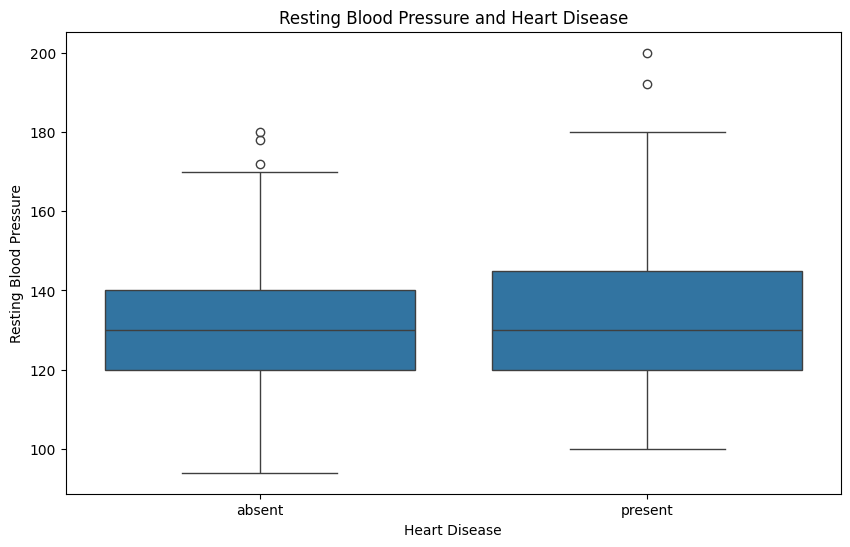

In [15]:
# Creating box plot
plt.clf()
plt.figure(figsize=(10, 6))
sns.boxplot(x='heart_disease', y='trestbps', data=heart)
plt.title('Resting Blood Pressure and Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Resting Blood Pressure')
plt.show()

Next, much like before, we will create two subsets of out data: One containing the `trestbps` of patients with heart disease, and one containing the `trestbps` of patients who do not have heart disease.

In [16]:
# Defining trestbps_hd
trestbps_hd = heart.trestbps[heart.heart_disease == 'present']

# Defining trestbps_no_hd
trestbps_no_hd = heart.trestbps[heart.heart_disease == 'absent']

Next, we will calculate the mean and median values of `trestbps` for each new subset of data, as well as the differences in each of those means and medians.

Here are our findings:

Means:
- `trestbps_hd_mean` = 134.57
- `trestbps_no_hd_mean` = 129.25
- `mean_diff2` = 5.32

Medians:
- `trestbps_hd_median` = 130.0
- `trestbps_no_hd_median` = 130.0
- `median_diff2` = 0

It is intersting to note here that there is no difference in the medians for the `trestbps` in patients with and without hear disease.

In [17]:
# Calculating means
trestbps_hd_mean = np.mean(trestbps_hd)
trestbps_no_hd_mean = np.mean(trestbps_no_hd)

# Printing individual means
print(trestbps_hd_mean)
print(trestbps_no_hd_mean)

# Calculating mean difference
mean_diff2 = trestbps_hd_mean - trestbps_no_hd_mean

# Printing the mean difference
print(mean_diff2)

134.568345323741
129.25
5.318345323740999


In [18]:
# Calculating medians
trestbps_hd_median = np.median(trestbps_hd)
trestbps_no_hd_median = np.median(trestbps_no_hd)

# Printing individual medians
print(trestbps_hd_median)
print(trestbps_no_hd_median)

# Calculating median difference
median_diff2 = trestbps_hd_median - trestbps_no_hd_median

# Printing the median difference
print(median_diff2)

130.0
130.0
0.0


Now, much like before, we would like to see if the average `trestbps` of a heart disease patient is significantly different than the average `trestbps` of a non-heart disease patient. First we must define our Null and Alternative hypotheses, as we are running another `two-tailed hypothesis test`:

Null: The average `trestbps` for a patient with heart disease IS equal to the average `trestbps` of a patient who does not have heart disease.

Alternative: The average `trestbps` for a patient with heart disease IS NOT equal to the average `trestbps` of a patient who does not have heart disease.

In [19]:
# Running our two-tailed hypothesis test (previously imported: ttest_ind)
tstat, pval = ttest_ind(trestbps_hd, trestbps_no_hd)

# Printing our p-value
print(pval)

0.008548268928594923


Here, while our p-value may not be as small as when we were running our test on `thalach`, it is still significant at the 0.01, 0.05, and 0.10 significance thresholds, meaning that there is a significant difference between the `trestbps` in patients with and without heart disease, meaning that we do reject the Null hypothesis.

The next thing that we would like to investigate within our dataset would be the relationship between a patient's `thalach` and the type of chest pain that patient experiences (`cp_type`).

To begin, we will first create a set of side-by-side boxplots in order to see whether the average `thalach` is significantly higher or lower for one type of chest pain when compared to another.

In our resulting plot, we can see that asymptomatic chest pain has a lower average `thalach` than the other three chest pain types which are all relatively similar to one another.

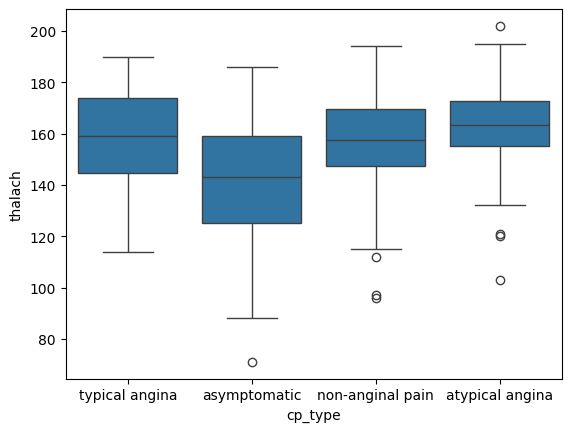

In [20]:
# Creating box plot of 'thalach' based on 'cp_type'
plt.clf()
sns.boxplot(x = heart.cp_type, y = heart.thalach)
plt.show()

To continue our investigation, we will assign the `thalach` values of our patients to variables based on the kind of chest pain that they experience:

In [21]:
# Storing thalach values based on 'cp_type' 
thalach_typical = heart.thalach[heart.cp_type == 'typical angina']
thalach_asymptom = heart.thalach[heart.cp_type == 'asymptomatic']
thalach_nonangin = heart.thalach[heart.cp_type == 'non-anginal pain']
thalach_atypical = heart.thalach[heart.cp_type == 'atypical angina']

Next, we will run a one tailed hypothesis test to adress the following Null and Alternative hypotheses:

Null: Patients with typical angina, non-anginal pain, atypical angina, and asymptomatic pain all have the same average `thalach`

Alternative: Patients with typical angina, non-anginal pain, atypical angina, and asymptomatic pain do not all have the same average `thalach`

Now, this test while seemingly similar to the ones run before, is very different in it's mechanical methodology. This test is addressing an association between a non-binary categorical variable (`cp_type`) and a quantitative variable (`thalach`).

So while we could use multiple two-tailed hypothesis tests, it would be much more beneficial to use an ANOVA.

In [22]:
# Running our ANOVA with previoulsy imported f_oneway
Fstat, pval = f_oneway(thalach_typical, thalach_asymptom, thalach_nonangin, thalach_atypical)

# Printing our p-value
print(pval)

1.9065505247702736e-10


In our results, we can see that we do have a p-value that represents significance at the 0.01, 0.05, and 0.10 significance thresholds. However, because we used and ANOVA, all we know is that there is at least one pair of chest pain types for which the patients have significantly different average `thalach`.

So, what we need to do next is figure out which pair is our pair with significantly different average `thalach` values.

For this hypothesis test, we will use Tukey's range test.

In [23]:
# Running our Tukey range test with previoulsy imported pairwise_tukeyhsd
output = pairwise_tukeyhsd(heart.thalach, heart.cp_type)

# Printing our output
print(output)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    asymptomatic  atypical angina  21.7394    0.0  12.7442 30.7347   True
    asymptomatic non-anginal pain  14.7264    0.0   7.2583 22.1945   True
    asymptomatic   typical angina   15.276 0.0081   2.9707 27.5812   True
 atypical angina non-anginal pain   -7.013 0.2481 -16.7587  2.7327  False
 atypical angina   typical angina  -6.4635 0.6213 -20.2702  7.3432  False
non-anginal pain   typical angina   0.5495 0.9995 -12.3145 13.4136  False
-------------------------------------------------------------------------


Within our results, for any pair that has a 'Reject' value of 'True', we can safely conclude that patients with those chest pain types have significantly different average `thalach` values during their exercise test.

From what we can see, we can see that asymptomatic `cp_type` has significantly different `thalach` values than the other three chest pain types, as we did see earlier within our box plot. However, one thing that is surprising here is that those patients with an asymptomatic chest pain type have a lower average `thalach` than those patients with any sort of other chest pain type.

For the final investigation within our dataset, we are going to now investigate the relationship between the kind of chest pain that a patient experiences and whether or not they have heart disease.

First, we will create a contingency table of `cp_type` and `heart_disease`.

In [24]:
# Creating our contingency table
Xtab = pd.crosstab(heart.cp_type, heart.heart_disease)

# Printing our table
print(Xtab)

heart_disease     absent  present
cp_type                          
asymptomatic          39      105
atypical angina       41        9
non-anginal pain      68       18
typical angina        16        7


Based on our table, it would seem that patients who have heart disease present tend to have asymptomatic pain types, while patients who do not have heart disease present seem to have differentiating kinds of chest pain.

This would also help us to explain why average `thalach` values are lower for those who experience asymptomatic chest pain.

Next, we will run a hypothesis test for the following Null and Alternative hypotheses:

Null: There is not an association between chest pain type and whether or not a patient is diagnosed with heart disease.

Alternative: There is an association between chest pain type and whether or not a patient is diagnosed with heart disease.

Again, it is important to note that this test is again unlike both of our previous hypothesis tests. Here, we are investigating an association between two categorical variables, so we should be using a Chi-Square test.

In [25]:
# Running our Chi-Square test
chi2, pval, dof, exp = chi2_contingency(Xtab)

# Printing p-value
print(pval)

1.2517106007837525e-17


From our resulting p-value, we can see that it is significant at the 0.01, 0.05, and 0.10 significance thresholds, which means that we can conclude that there is a significant association between these two variables.